### Exercise 1

What would happen if we were to initialize the weights to zero. Would the algorithm still work? What if we initialized the parameters with variance 1000 rather than $0.01 ?$

In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [4]:
class LinearRegressionScratch(d2l.Module):  #@save
    def __init__(self, num_inputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.zeros(size = (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [36]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [37]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

In [38]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [39]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [40]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

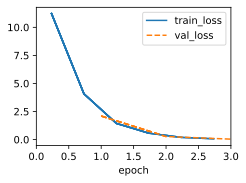

In [10]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [11]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.0851, -0.1498])
error in estimating b: tensor([0.2076])


Linear regression can still learn the true parameters. In linear regression, there is only weight per input features so there is no symmetry to break. However, in neural network, hidden nuerons are interchangeable. If two neuros start with same wights, they will receive same gradient and end up getting same updates. They remain identical. So instead of learning multiple different features, my network effectively behaves like it has only one hidden neuron. This is the symmetry problem.

In [26]:
class LinearRegressionScratch(d2l.Module):  #@save
    def __init__(self, num_inputs, lr, sigma = 1000):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, size = (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

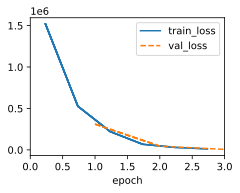

In [32]:
model = LinearRegressionScratch(2, lr=0.03, sigma=1000)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [33]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([-82.2138,  79.6324])
error in estimating b: tensor([-11.6192])


The model is not able to learn the true parameters with 3 epochs and a learning rate of 0.03; Since we intialize $\omega$ with magnitude ~1000, gradients will be huge.

### Exercise 2

Assume that you are Georg Simon Ohm trying to come up with a model for resistance that relates voltage and current. Can you use automatic differentiation to learn the parameters of your model?

In [51]:
class OhmData(d2l.DataModule):      #@save
    """Synthetic data for linear regression."""
    def __init__(self, r, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.I = torch.randn(n, 1)
        noise = torch.randn(n, 1) * noise
        self.V = self.I * r + noise

In [74]:
@d2l.add_to_class(d2l.DataModule)  #@save
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(OhmData)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.I, self.V), train, i)

In [60]:
data = OhmData(r=torch.tensor([10]))
I, V = next(iter(data.train_dataloader()))
print('I shape:', I.shape, '\nV shape:', V.shape)

I shape: torch.Size([32, 1]) 
V shape: torch.Size([32, 1])


In [61]:
class OhmRegression(d2l.Module):  #@save
    def __init__(self, num_inputs, lr, sigma = 0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, size = (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [62]:
@d2l.add_to_class(OhmRegression)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [63]:
@d2l.add_to_class(OhmRegression)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

In [64]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [65]:
@d2l.add_to_class(OhmRegression)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [66]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

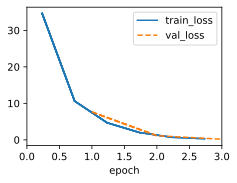

In [67]:
model = OhmRegression(1, lr=0.03)
data = OhmData(r=torch.tensor([10]))
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [69]:
with torch.no_grad():
    print(f'error in estimating r: {data.r - model.w.reshape(data.r.shape)}')

error in estimating r: tensor([0.5715])


### Exercise 3

Can you use Planck's Law to determine the temperature of an object using spectral energy density? For reference, the spectral density $B$ of radiation emanating from a black body is $B(\lambda, T)=\frac{2 h c^2}{\lambda^5} \cdot\left(\exp \frac{h c}{\lambda k T}-1\right)^{-1}$. Here $\lambda$ is the wavelength, $T$ is the temperature, $c$ is the speed of light, $h$ is Planck's constant, and $k$ is the Boltzmann constant. You measure the energy for different wavelengths $\lambda$ and you now need to fit the spectral density curve to Planck's law.

In [88]:
class PlanckData(d2l.DataModule):      #@save
    """Synthetic data for linear regression."""
    def __init__(self, T, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val

        # Physical constants (SI)
        self.h = 6.62607015e-34     # Planck constant
        self.c = 2.99792458e8       # speek of light
        self.k = 1.380649e-23       # Boltzmann constant

        # Wavelength range around the peak (Wien's displacment law)
        lpeak = 2.898e-3 / T
        lmin, lmax = 0.2 * lpeak, 5.0 * lpeak

        # Generate wavelengths (n samples)
        self.l = torch.linspace(lmin, lmax, n).reshape(-1, 1)

        # Planck law
        self.noise = torch.randn(n, 1) * noise
        self.B = (2*self.h*self.c**2) / self.l**5 / (torch.exp(self.h*self.c / (self.l*self.k*self.T)) - 1) + self.noise

In [89]:
@d2l.add_to_class(d2l.DataModule)  #@save
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(PlanckData)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.l, self.B), train, i)

In [90]:
data = PlanckData(T=3000)
l, B = next(iter(data.train_dataloader()))
print('l shape:', l.shape, '\nB shape:', B.shape)

l shape: torch.Size([32, 1]) 
B shape: torch.Size([32, 1])


In [91]:
class PlanckRegression(d2l.Module):  #@save
    def __init__(self, num_inputs, lr, sigma = 0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, size = (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [92]:
@d2l.add_to_class(PlanckRegression)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [93]:
@d2l.add_to_class(PlanckRegression)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

In [94]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [95]:
@d2l.add_to_class(PlanckRegression)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [96]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

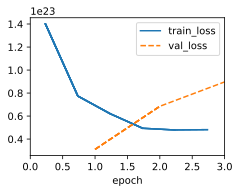

In [97]:
model = PlanckRegression(1, lr=0.03)
data = PlanckData(T=3000)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

### Exercise 4

What are the problems you might encounter if you wanted to compute the second derivatives of the loss? How would you fix them?

If we tell PyTorhc to keep the computation graph after `loss.backward()`, it require storing all intermiediate activations and all intermediate gradients. This can easily multiply memory usage. For deep networks, Hessians are massive. For example, if we have 1 million parameters, full Hessian has 1 million times 1 million many parameters. The full Hessian is impractical.

Maybe we can try to approximate the Hessian matrix using Diagonal approximation.

### Exercise 5

Why is the reshape method needed in the loss function?

Typically:
* w shape = (d, )

This is a 1-D tensor (a vector)

But Matrix multiplication expects:
* (n ,d) @ (d, 1)

not
* (n, d) @ (d, )

`.reshape(-1, 1)` converts (d, ) -> (d, 1)

`-1` means "infer this dimension automatically"

So

### Exercise 6

Experiment using different learning rates to find out how quickly the loss function value drops. Can you reduce the error by increasing the number of epochs of training?

### Exercise 7

If the number of examples cannot be divided by the batch size, what happens to data_iter at the end of an epoch?

If the dataset size is not divisible by the batch size, the last batch will be smaller.

In [98]:
data = PlanckData(T=3000, num_train=1000, batch_size=32)
loader = data.train_dataloader()

for i, batch in enumerate(loader):
    X, y = batch
    print(f"Batch {i}: size {X.shape[0]}")

Batch 0: size 32
Batch 1: size 32
Batch 2: size 32
Batch 3: size 32
Batch 4: size 32
Batch 5: size 32
Batch 6: size 32
Batch 7: size 32
Batch 8: size 32
Batch 9: size 32
Batch 10: size 32
Batch 11: size 32
Batch 12: size 32
Batch 13: size 32
Batch 14: size 32
Batch 15: size 32
Batch 16: size 32
Batch 17: size 32
Batch 18: size 32
Batch 19: size 32
Batch 20: size 32
Batch 21: size 32
Batch 22: size 32
Batch 23: size 32
Batch 24: size 32
Batch 25: size 32
Batch 26: size 32
Batch 27: size 32
Batch 28: size 32
Batch 29: size 32
Batch 30: size 32
Batch 31: size 8


### Exercise 8

Try implementing a different loss function, such as the absolute value loss `(y_hat - d2l.reshape(y, y_hat.shape)).abs().sum()`.

1. Check what happens for regular data.

2. Check whether there is a difference in behavior if you actively perturb some entries, such as $y_5 = 10000$, of y

3. Can you think of a cheap solution for combining the best aspects of squared loss and absolute value loss? Hint: how can you avoid really large gradient values?

#### 8.1

In [9]:
class LinearRegressionScratch(d2l.Module):  #@save
    def __init__(self, num_inputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.zeros(size = (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [10]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [ ]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = (y_hat - d2l.reshape(y, y_hat.shape)).abs()
    return l.mean()

In [12]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [13]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [14]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

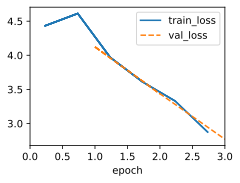

In [ ]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [16]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 1.2182, -2.2189])
error in estimating b: tensor([2.2237])


The regular data do not have outlier. The update using the absolute error look jittery because mant samples flip sign as we move around. Instead of a gradient that scales with error like MSE, the gradient is basically a sign in the absolute error case. 

#### 8.2

MSE

In [70]:
class LinearRegressionScratch(d2l.Module):  #@save
    def __init__(self, num_inputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.zeros(size = (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [71]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [72]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

In [73]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [74]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [75]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

In [76]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
with torch.no_grad():
    data.y[5] = 10000

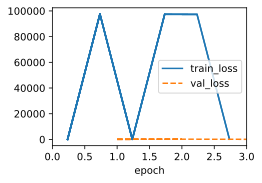

In [77]:
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [78]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([-6.3710,  6.1437])
error in estimating b: tensor([-7.2371])


Absolute Value

In [79]:
class LinearRegressionScratch(d2l.Module):  #@save
    def __init__(self, num_inputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.zeros(size = (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

In [80]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

In [81]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = (y_hat - d2l.reshape(y, y_hat.shape)).abs()
    return l.mean()

In [82]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [83]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

In [84]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

In [85]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
with torch.no_grad():
    data.y[5] = 10000

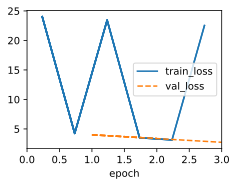

In [86]:
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [87]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 1.3634, -2.2394])
error in estimating b: tensor([2.2200])


With MSE, squared loss penalizes large errors quadratically. Therefore, that one point dominates the loss and gradient becomes extremely large. Therefore, model shifts heavily to reduce that one error and fit becomes distorted. 

With absolute loss, gradient is still large, but gradient magnitude is constant (±1) and therefore, this particular point does not dominate gradient

Overall, when our data have outliers, l1 loss is more robust than l2 loss.

#### 8.3

We can try to utilize Huber loss (a.k.a. Smooth L1)

It behaves like:
* squared loss when the error is small (smooth + fast convergence near optimum)
* absolute loss when the error is large (robust to outliers + no exploding gradients)

Formally, for residual $r=y-\hat{y}$ :
$$
\ell_\delta(r)= \begin{cases}\frac{1}{2} r^2 & |r| \leq \delta \\ \delta\left(|r|-\frac{1}{2} \delta\right) & |r|>\delta\end{cases}
$$
Derivative:
* if $|r| \leq \delta: \ell^{\prime}(r)=r$ (like MSE)
* if $|r|>\delta: \ell^{\prime}(r)=\delta \operatorname{sign}(r)$ (capped, like L1)
So it avoids really large gradient values automatically.

### Exercise 9

Why do we need to reshuffle the dataset? Can you design a case where a maliciously constructed dataset would break the optimization algorithm otherwise?

#### Without Reshuffle

In [382]:
class MaliciousData(d2l.DataModule):  #@save
    def __init__(self, w, noise=0.01, num_train=1000, num_val=1000, batch_size=32):
        super().__init__()
        self.save_hyperparameters()

        # Training inputs: first half negative, second half positive
        n1 = self.num_train // 2
        n2 = self.num_train - n1
        X_first = torch.linspace(-20, 10, n1).reshape(-1, 1)
        X_second = torch.linspace(0, 1, n2).reshape(-1, 1)
        self.X_train = torch.cat([X_first, X_second], dim=0)

        # Validation inputs: anything
        self.X_val = torch.linspace(-20, 1, self.num_val).reshape(-1, 1)

        self.X = torch.cat([self.X_train, self.X_val], dim=0)
        self.Y = self.X * w + torch.randn(self.X.shape) * noise

In [383]:
@d2l.add_to_class(d2l.DataModule)  #@save
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(MaliciousData)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.Y), False, i)

In [385]:
data = MaliciousData(w = 1)
X, Y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\nY shape:', Y.shape)

X shape: torch.Size([32, 1]) 
Y shape: torch.Size([32, 1])


In [386]:
class MaliciousRegression(d2l.Module):  #@save
    def __init__(self, num_inputs, lr, sigma = 0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, size = (num_inputs, 1), requires_grad=True)

In [387]:
@d2l.add_to_class(MaliciousRegression)  #@save
def forward(self, X):
    return torch.matmul(X, self.w)

In [388]:
@d2l.add_to_class(MaliciousRegression)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

In [389]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [390]:
@d2l.add_to_class(MaliciousRegression)  #@save
def configure_optimizers(self):
    return SGD([self.w], self.lr)

In [391]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

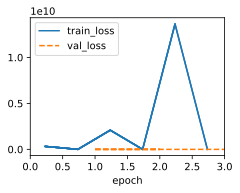

In [393]:
model = MaliciousRegression(1, lr=0.03)
data = MaliciousData(w = 1)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [395]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w}')

error in estimating w: tensor([[16.5398]])


#### With Reshuffle

In [370]:
class MaliciousData(d2l.DataModule):  #@save
    def __init__(self, w, noise=0.01, num_train=1000, num_val=1000, batch_size=32):
        super().__init__()
        self.save_hyperparameters()

        # Training inputs: first half negative, second half positive
        n1 = self.num_train // 2
        n2 = self.num_train - n1
        X_first = torch.linspace(-20, 10, n1).reshape(-1, 1)
        X_second = torch.linspace(0, 1, n2).reshape(-1, 1)
        self.X_train = torch.cat([X_first, X_second], dim=0)

        # Validation inputs: anything
        self.X_val = torch.linspace(-20, 1, self.num_val).reshape(-1, 1)

        self.X = torch.cat([self.X_train, self.X_val], dim=0)
        self.Y = self.X * w + torch.randn(self.X.shape) * noise

In [371]:
@d2l.add_to_class(d2l.DataModule)  #@save
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    tensors = tuple(a[indices] for a in tensors)
    dataset = torch.utils.data.TensorDataset(*tensors)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)

@d2l.add_to_class(MaliciousData)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.Y), train, i)

In [372]:
data = MaliciousData(w = 1.0)
X, Y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\nY shape:', Y.shape)

X shape: torch.Size([32, 1]) 
Y shape: torch.Size([32, 1])


In [373]:
class MaliciousRegression(d2l.Module):  #@save
    def __init__(self, num_inputs, lr, sigma = 0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, size = (num_inputs, 1), requires_grad=True)

In [374]:
@d2l.add_to_class(MaliciousRegression)  #@save
def forward(self, X):
    return torch.matmul(X, self.w)

In [375]:
@d2l.add_to_class(MaliciousRegression)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

In [376]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [377]:
@d2l.add_to_class(MaliciousRegression)  #@save
def configure_optimizers(self):
    return SGD([self.w], self.lr)

In [378]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

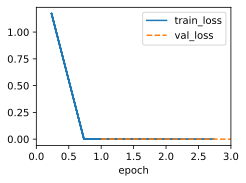

In [379]:
model = MaliciousRegression(1, lr=0.03)
data = MaliciousData(w = 1)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [381]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w}')

error in estimating w: tensor([[2.8849e-05]])


Make two blocks in training:
- Block A: very large feature magnitudes → enormous gradients
- Block B: normal magnitudes (e.g., $x \in[0,1]$ )

Without reshuffling, the learning algorithm will make the parameter jump around if we train using the first part only.